# Logarithmic Scales and Twin Axes

As your software projects grow, you will face two common data plotting challenges:

1.  **Massive Scale Differences (Logarithmic Scales)**:
    Imagine plotting your website pageviews. Some pages have 10 views, while your homepage has 10,000,000 views. If you plot them on a normal linear Y-axis, the page with 10 views looks like exactly `0` because 10 is too tiny compared to 10 million.
    By changing the axis to a **Logarithmic Scale** (`plt.yscale('log')`), each major tick on the axis multiplies by 10 (e.g., $10^0=1$, $10^1=10$, $10^2=100$, $10^3=1000$, $10^4=10000$). This allows you to inspect extremely small and extremely large numbers clearly on the same chart.

2.  **Different Units on One Chart (Twin Y-Axes)**:
    What if you want to display both the **CPU Usage (in %)** and the **Memory Usage (in Megabytes)** of your server over time?
    These are two completely different metrics with different scales and units. You cannot plot them on a single Y-axis!
    Matplotlib allows us to create a **Twin Y-Axis** using `.twinx()`. This creates a secondary Y-axis on the right side of the chart, sharing the same X-axis (Time).

### Simple Explanation with an Everyday Analogy
*   **Logarithmic Scale**: Imagine taking a photo of a tiny ant standing next to a massive giraffe. In a normal photo, the ant is a single pixel you cannot see. A logarithmic scale is like a magical filter that adjusts the sizes so you can see the ant's legs and the giraffe's neck clearly at the same time.
*   **Twin Axis**: Imagine a dual-display watch. The clock hands show local time, while a small digital display at the bottom shows temperature. They share the same watch body (X-axis) but display different things (Y-axes).

#### Using Logarithmic Scale for Wide Ranges
Let's see what happens to an exponential sequence when plotted with a logarithmic scale.



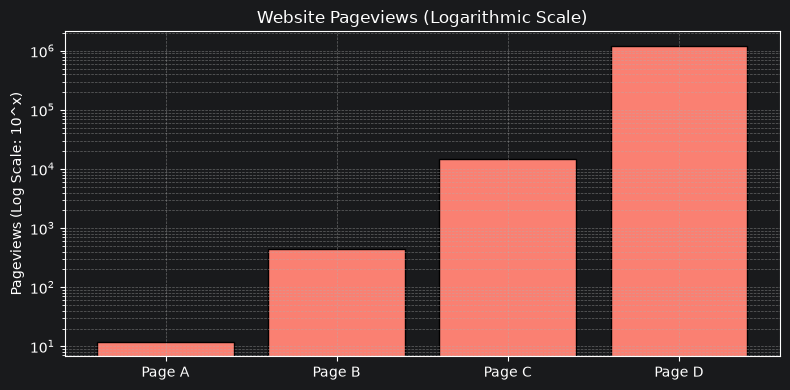

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data ranging from 10 to 1,000,000
x = np.array(["Page A", "Page B", "Page C", "Page D"])
views = np.array([12, 450, 15000, 1200000])

plt.figure(figsize=(8, 4))
plt.bar(x, views, color='salmon', edgecolor='black')

# Set Y-axis scale to Logarithmic
plt.yscale('log')

plt.title("Website Pageviews (Logarithmic Scale)")
plt.ylabel("Pageviews (Log Scale: 10^x)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
# plt.savefig('log_scale.png')

#### Creating a Twin Y-Axis (`twinx()`)
Let's plot CPU Usage (%) and Memory (MB) together over a 5-hour timeline.

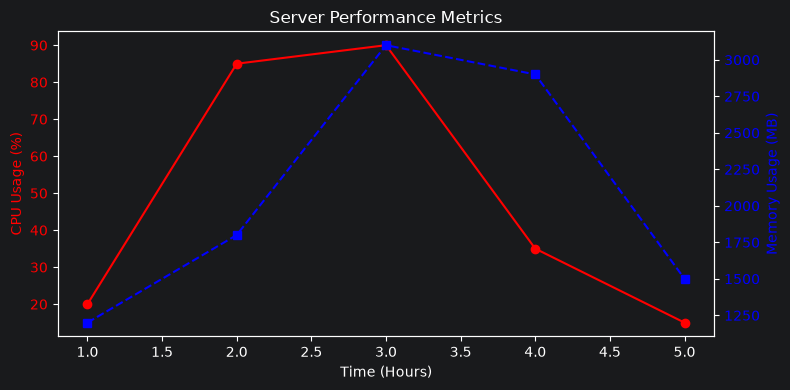

In [2]:
import matplotlib.pyplot as plt
import numpy as np

time = np.array([1, 2, 3, 4, 5]) # Hours
cpu_pct = np.array([20, 85, 90, 35, 15]) # %
mem_mb = np.array([1200, 1800, 3100, 2900, 1500]) # MB

fig, ax1 = plt.subplots(figsize=(8, 4))

# Plot CPU on the Left Y-Axis (ax1)
ax1.plot(time, cpu_pct, color='red', marker='o', label="CPU (%)")
ax1.set_xlabel("Time (Hours)")
ax1.set_ylabel("CPU Usage (%)", color='red')
ax1.tick_params(axis='y', labelcolor='red')

# Create a twin axis sharing the same X-axis
ax2 = ax1.twinx()

# Plot Memory on the Right Y-Axis (ax2)
ax2.plot(time, mem_mb, color='blue', marker='s', ls='--', label="Memory (MB)")
ax2.set_ylabel("Memory Usage (MB)", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title("Server Performance Metrics")
fig.tight_layout()
# plt.savefig('twin_axes.png')

### Common Mistakes Beginners Make
1.  **Forgetting to color-code labels on Twin Axes**: If you don't make the left axis tick labels red and the right axis tick labels blue, viewers will get confused about which line belongs to which axis! Always use `ax1.tick_params(labelcolor='color')`.
2.  **Passing zero or negative numbers to Log Scale**: Mathematically, $\log(0)$ and $\log(	ext{negative})$ are undefined! If your dataset contains zeros or negative values, setting `yscale('log')` will result in errors or blank points on your plot.


#### Exercise 1 (Easy)
Write a script that creates a 1D array of values `y = [10, 100, 1000, 10000, 100000]`. Plot them on a line graph, and apply a logarithmic scale on the Y-axis. What does the line look like on a log scale? Explain why.

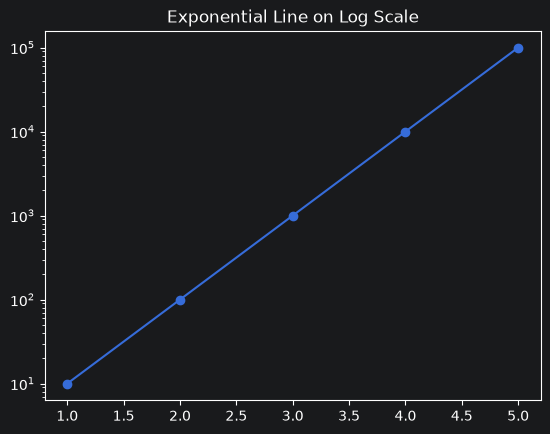

In [3]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(1, 6)
y = np.array([10, 100, 1000, 10000, 100000])

plt.plot(x, y, marker='o')
plt.yscale('log')
plt.title("Exponential Line on Log Scale")
plt.show()

*Explanation*: The line looks perfectly **straight**! This is because the values are growing exponentially (multiplying by 10 each time), and the logarithmic scale also multiplies by 10 at each step on the axis. An exponential curve becomes a straight line on a log scale.


#### Exercise 2 (Medium)
You are monitoring a network database over a 5-minute interval:
```python
minutes = np.arange(1, 6)
connections = [100, 120, 130, 115, 110] # Connections count
response_time = [5, 6, 25, 7, 5] # Response time in milliseconds
```
Plot both lines on the same figure using a twin Y-axis. The left axis should show Connection count (in Green), and the right axis should show Response Time in ms (in Orange). Add proper titles and colored ticks.


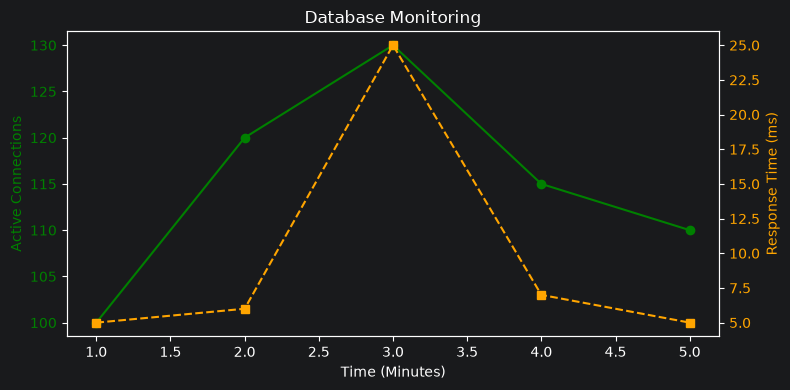

In [4]:
import matplotlib.pyplot as plt
import numpy as np

minutes = np.arange(1, 6)
connections = [100, 120, 130, 115, 110]
response_time = [5, 6, 25, 7, 5]

fig, ax1 = plt.subplots(figsize=(8, 4))

# Left Y-Axis
ax1.plot(minutes, connections, color='green', marker='o', label="Connections")
ax1.set_xlabel("Time (Minutes)")
ax1.set_ylabel("Active Connections", color='green')
ax1.tick_params(axis='y', labelcolor='green')

# Twin axis
ax2 = ax1.twinx()

# Right Y-Axis
ax2.plot(minutes, response_time, color='orange', marker='s', ls='--', label="Response Time")
ax2.set_ylabel("Response Time (ms)", color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title("Database Monitoring")
fig.tight_layout()